# 🤖 Algoritmos de Diferença Temporal — Notebook Prático
## Aprendizado por Reforço: TD(0) · SARSA · Q-Learning · Expected SARSA

---

### Objetivo
Compreender na prática o funcionamento dos algoritmos de **Diferença Temporal (TD)**,
explorando o efeito de parâmetros como `alpha`, `gamma`, `noise` e `living_reward`
em ambientes progressivamente mais desafiadores.

### Estrutura do Notebook

| Módulo | Tema | Destaque |
|--------|------|----------|
| **0** | Setup & Fundamentos | Configuração, imports, recap teórico |
| **1** | TD(0) — Avaliação de Política | GridWorld 3×4: predição, efeito de α |
| **2** | SARSA & Q-Learning — Controle | GridWorld 3×4: γ, noise, living_reward |
| **3** | CliffWorld | O experimento clássico: on-policy vs off-policy |
| **4** | Comparação Sistemática | GridWorld 5×5: 4 algoritmos, variância, sensibilidade |
| **5** | Caso Real | Logística urbana de entrega |

### Como usar este notebook
- 📝 Células com **TODO** exigem que você complete o código
- ▶ Células **prontas** — execute e observe os resultados
- 💡 Células de **Insight** — reflexões sobre os experimentos

---
## Módulo 0 — Setup

### Carregando os arquivos do curso

Escolha **uma** das duas opções abaixo antes de executar:

**Opção A — Upload manual** (primeira vez no Colab): execute a célula e faça upload
dos arquivos `environment.py`, `algorithms.py` e `visualization.py`.

**Opção B — Repositório GitHub**: comente o bloco de upload e descomente o `git clone`.

In [1]:
import os, sys

# ─── Opção A: Upload manual (Google Colab) ─────────────────────
try:
    from google.colab import files as colab_files
    IN_COLAB = True
    print("Google Colab detectado.")
    print("Faça o upload dos 3 arquivos: environment.py, algorithms.py, visualization.py")
    uploaded = colab_files.upload()
    print(f"\nArquivos recebidos: {list(uploaded.keys())}")
except ImportError:
    IN_COLAB = False
    print("Ambiente local detectado — arquivos devem estar no diretório atual.")

# ─── Opção B: Clonar do GitHub ─────────────────────────────────
# GITHUB_URL = "https://github.com/SEU_USUARIO/SEU_REPO.git"
# os.system(f"git clone {GITHUB_URL}")
# sys.path.insert(0, './SEU_REPO')

# ─── Verificação ───────────────────────────────────────────────
arquivos = ['environment.py', 'algorithms.py', 'visualization.py']
faltando = [f for f in arquivos if not os.path.exists(f)]
if faltando:
    print(f"\n⚠️  Arquivos não encontrados: {faltando}")
    print("Verifique o upload ou o caminho do repositório.")
else:
    print("\n✅ Todos os arquivos encontrados! Execute a próxima célula.")

Ambiente local detectado — arquivos devem estar no diretório atual.

✅ Todos os arquivos encontrados! Execute a próxima célula.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Seed para reprodutibilidade dos experimentos
SEED = 42
np.random.seed(SEED)

# ─── Módulos do curso ──────────────────────────────────────────
from environment import (GridWorld, create_classic_gridworld,
                         create_custom_gridworld, create_cliff_world_2,
                         print_gridworld_info)

from algorithms import (td_zero_prediction, sarsa, q_learning, expected_sarsa,
                        value_iteration, get_greedy_policy, state_to_idx,
                        epsilon_greedy_action)

from visualization import (visualize_gridworld, visualize_q_values,
                            visualize_q_table_detailed, plot_learning_curves,
                            plot_value_heatmap, plot_q_value_heatmap,
                            compare_algorithms, print_q_table,
                            convert_dp_v_to_dict, convert_dp_policy_to_dict)

print(f"✅ Módulos importados com sucesso! NumPy {np.__version__}")

✅ Módulos importados com sucesso! NumPy 1.24.3


---
## Recap Teórico — Consulte sempre que precisar durante os experimentos

### 🔵 V(s) versus Q(s, a) — a distinção mais importante

| | **V(s)** | **Q(s, a)** |
|--|---------|------------|
| **Pergunta** | "Qual o valor de *estar* neste estado?" | "Qual o valor de *estar aqui e escolher esta ação*?" |
| **Depende de** | Política π seguida a partir de s | Ação a escolhida + política π a partir de s' |
| **Usado em** | TD(0) — avaliação de política fixa | SARSA, Q-Learning, Expected SARSA — controle |
| **Relação** | V(s) = Σ_a π(a\|s) · Q(s,a) | V*(s) = max_a Q*(s,a) |

> 💡 **Intuição:** V(s) é uma *média ponderada* de todos os Q(s,a) sob a política π.  
> Para *melhorar* uma política, precisamos de Q(s,a) — assim sabemos qual ação escolher.

---

### 📐 As quatro equações de atualização (consulte durante os TODOs!)

**TD(0)** — aprende *V(s)*, avaliação de política fixa:
```
V(s) ← V(s) + α · [ r + γ·V(s')  -  V(s) ]
                    └── td_target ─┘  └─ V atual ─┘
```

**SARSA** — aprende *Q(s,a)*, on-policy (usa ação que SERÁ tomada):
```
Q(s,a) ← Q(s,a) + α · [ r + γ·Q(s', a')  -  Q(s,a) ]
                                    ↑ a' é a ação REAL (ε-greedy)
```

**Q-Learning** — aprende *Q*(s,a)*, off-policy (usa melhor ação POSSÍVEL):
```
Q(s,a) ← Q(s,a) + α · [ r + γ·max_a' Q(s', a')  -  Q(s,a) ]
                                    ↑ MÁXIMO sobre todas as ações
```

**Expected SARSA** — aprende *Q(s,a)*, usa esperança sob π:
```
Q(s,a) ← Q(s,a) + α · [ r + γ · Σ_a π(a|s') Q(s',a)  -  Q(s,a) ]
                                    ↑ expectativa ponderada pela política
```

---

### 🎯 On-policy vs Off-policy — o coração da diferença entre SARSA e Q-Learning

| | **On-policy** | **Off-policy** |
|--|--------------|----------------|
| **O que aprende** | Política que **gera** a experiência | Política diferente (geralmente ótima) |
| **Algoritmos** | TD(0), SARSA | Q-Learning, Expected SARSA* |
| **Analogia** | "Avalio o que faço" | "Aprendo o ideal, mesmo explorando diferente" |
| **No CliffWorld** | Aprende rota **segura** (evita beira do precipício) | Aprende rota **ótima** (bordeja o precipício) |

> *Expected SARSA com ε→0 converge para Q-Learning (off-policy).

> ⚠️ **A diferença entre SARSA e Q-Learning é UMA linha de código:**  
> SARSA usa `Q[s', a']` → ação que **será** tomada  
> Q-Learning usa `np.max(Q[s', :])` → melhor ação **possível**

---
## Módulo 1 — TD(0): Avaliação de Política no GridWorld 3×4

### O que vamos explorar
- O **GridWorld clássico** de Russell & Norvig (3 linhas × 4 colunas)
- Como **TD(0)** estima V(s) seguindo uma política fixa, *sem o modelo do ambiente*
- O efeito do parâmetro **α** na velocidade e estabilidade da convergência

### Layout do ambiente

```
[ ] [ ] [ ] [+1]   ← linha 0   (+1 = terminal positivo)
[ ] [■] [ ] [-1]   ← linha 1   (-1 = terminal negativo / ■ = parede)
[S] [ ] [ ] [ ]    ← linha 2   (S = estado inicial)
 0   1   2   3
```

### Por que TD(0) e não apenas Programação Dinâmica?

| | TD(0) (Model-Free) | Value Iteration (Model-Based) |
|--|-------------------|-------------------------------|
| **Precisa do modelo P(s'\|s,a)?** | ❌ Não | ✅ Sim |
| **Atualiza quando?** | A cada passo (online) | Varrendo todos os estados |
| **Fonte de informação** | Experiência real (s, a, r, s') | Modelo de transição |
| **Aplicação prática** | Ambientes desconhecidos | Ambientes modeláveis |

**TD(0) é um método *model-free*:** aprende apenas de transições observadas,
sem nunca precisar saber P(s'|s,a). Isso é fundamental para problemas reais.

INFORMAÇÕES DO GRIDWORLD
Dimensões: 3 linhas x 4 colunas
Total de estados: 11
Paredes: 1
Estados terminais: 2
Fator de desconto (γ): 0.9
Ruído: 0.2
Living reward: -0.04
Ações disponíveis: ['N', 'S', 'L', 'O']

Paredes: [(1, 1)]

Estados terminais:
  (0, 3): reward = 1.0
  (1, 3): reward = -1.0


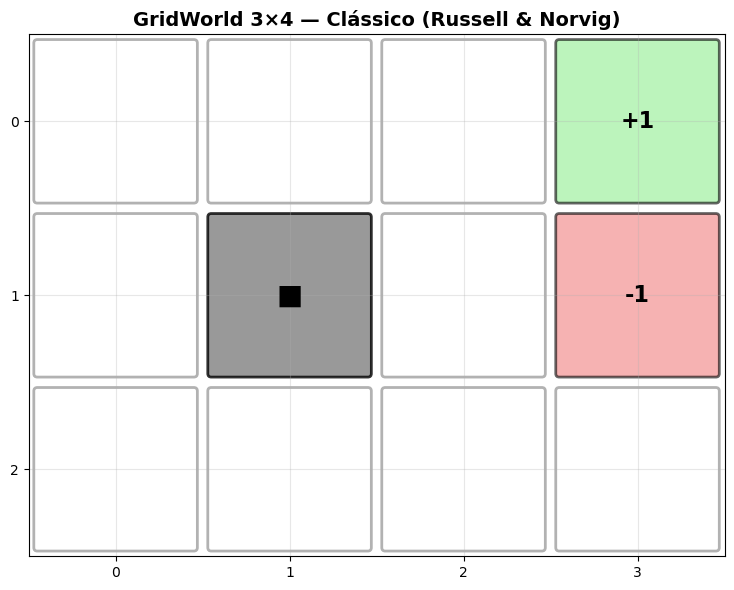

In [3]:
# ▶ EXECUTE — Experimento 1.1: Visualizando o GridWorld Clássico
# ──────────────────────────────────────────────────────────────

gw = create_classic_gridworld()
print_gridworld_info(gw)
visualize_gridworld(gw, title="GridWorld 3×4 — Clássico (Russell & Norvig)")

### Experimento 1.2 — Implementando TD(0)

Antes de usar a versão completa da biblioteca, você vai implementar a **equação de atualização TD(0)**.

A função `meu_td_zero` tem toda a estrutura pronta — você precisa completar apenas as **3 linhas marcadas com TODO**.

> 💡 **Dica:** consulte a fórmula no recap acima:
> `td_target = r + γ · V(s')` e `V(s) = V(s) + α · (td_target - V(s))`

In [ ]:
# 📝 TODO 1/4 — Implemente a atualização TD(0)
# ──────────────────────────────────────────────────────────────

def meu_td_zero(gridworld, policy, n_episodes=500, alpha=0.1):
    """
    TD(0) para avaliação de política.
    Estima V^pi(s) para todos os estados não-terminais,
    SEM precisar do modelo de transição P(s'|s,a).
    """
    V     = {s: 0.0 for s in gridworld.states}
    gamma = gridworld.gamma

    for _ in range(n_episodes):
        # Começa em estado não-terminal aleatório
        nao_term = [s for s in gridworld.states if not gridworld.is_terminal(s)]
        state = nao_term[np.random.randint(len(nao_term))]

        while not gridworld.is_terminal(state):
            action     = policy[state]
            next_state, reward = gridworld.sample_transition(state, action)

            # ══════════════════════════════════════════════════════════
            # 📝 TODO: Complete as três linhas abaixo
            #
            # Fórmula: V(s) ← V(s) + α · [ r + γ·V(s') - V(s) ]
            #                              └── td_target ──┘
            #                          └────── td_error ──────┘
            #
            # Variáveis disponíveis:
            #   reward           → r         (recompensa observada)
            #   gamma            → γ         (fator de desconto do gridworld)
            #   V[next_state]    → V(s')     (estimativa atual do próximo estado)
            #   V[state]         → V(s)      (estimativa a ser atualizada)
            #   alpha            → α         (taxa de aprendizado)
            # ══════════════════════════════════════════════════════════

            td_target = ___  # r + γ · V(s')  ← bootstrap com estimativa atual
            td_error  = ___  # diferença entre o alvo e a estimativa de V(s)
            V[state]  = ___  # V(s) + α · td_error

            # ══════════════════════════════════════════════════════════

            state = next_state
    return V

# ─── Política de teste: sempre tentar ir para Leste ou Norte ───
politica_le = {s: ('L' if s[1] < 3 else 'N')
               for s in gw.states if not gw.is_terminal(s)}

V_meu = meu_td_zero(gw, politica_le, n_episodes=800, alpha=0.1)

# ─── Referência: Value Iteration (tem acesso ao modelo completo) ─
V_dp_arr, _, _ = value_iteration(gw, gamma=gw.gamma)
V_dp = convert_dp_v_to_dict(V_dp_arr, gw)

# ─── Comparação numérica ───────────────────────────────────────
print("Comparação: TD(0) implementado  vs  Value Iteration (referência DP)")
print(f"{'Estado':<12} {'V_TD0 (seu)':<20} {'V_DP (ref.)'}")
print("─" * 50)
for s in sorted(gw.states):
    if not gw.is_terminal(s) and s not in gw.walls:
        print(f"{str(s):<12} {V_meu.get(s,0):<20.4f} {V_dp.get(s,0):.4f}")

# ─── Visualização lado a lado ─────────────────────────────────
visualize_gridworld(gw, values=V_meu, policy=politica_le,
                    title="TD(0) — Sua implementação  [V(s)]")
visualize_gridworld(gw, values=V_dp,
                    title="Value Iteration — Referência [V*(s)]")

### 💡 Insights — Experimento 1.2

**O que observar:**

1. **Os valores de V(s) convergem para estimativas razoáveis** mesmo sem o modelo.
   TD(0) usa apenas experiência real — tuplas (s, a, r, s'). Esse é o poder dos métodos model-free.

2. **V(s) não é Q(s,a):** Com V(s) sozinho, para melhorar a política precisaríamos conhecer
   P(s'|s,a) (calcular qual ação maximiza V(s')). Por isso algoritmos de *controle*
   aprendem diretamente Q(s,a) — sem depender do modelo.

3. **Estados mais próximos ao terminal `+1` têm valores maiores.**
   Sob essa política, V(s) reflete o retorno esperado *seguindo aquela política* — não o ótimo global.

4. **A diferença em relação ao DP existe**, mas TD(0) converge para V^π (e não para V*)
   porque está avaliando uma política específica, não otimizando.

> **Diferença visual:** Note que o DP usou o modelo completo para chegar em V* (ótimo),
> enquanto TD(0) estimou V^π para uma política fixa específica. São perguntas diferentes.

### Experimento 1.3 — Efeito de α (Taxa de Aprendizado)

Como α controla o balanço entre **nova experiência** e **conhecimento acumulado**?

- **α grande:** aprende rápido, mas pode oscilar — cada nova experiência "desaprende" muito do passado
- **α pequeno:** aprende devagar, mas de forma estável — experiências antigas têm mais peso
- **α = 1:** descarta completamente o histórico (memória = 0, como um perceptron sem momentum)

In [ ]:
# ▶ EXECUTE — Experimento 1.3: Análise do parâmetro α
# ──────────────────────────────────────────────────────────────

ALPHAS          = [0.01, 0.05, 0.1, 0.3, 0.5]
N_TOTAL         = 1000
N_CHECKPOINTS   = 20
ESTADO_ALVO     = (2, 0)   # estado inicial — mais interessante de observar

resultados_alpha = {}

for alpha in ALPHAS:
    hist_V = []
    V_curr = {s: 0.0 for s in gw.states}
    gamma  = gw.gamma
    bloco  = N_TOTAL // N_CHECKPOINTS

    for _ in range(N_CHECKPOINTS):
        for _ in range(bloco):
            nao_term = [s for s in gw.states if not gw.is_terminal(s)]
            state = nao_term[np.random.randint(len(nao_term))]
            while not gw.is_terminal(state):
                action          = politica_le[state]
                next_state, r   = gw.sample_transition(state, action)
                td_t            = r + gamma * V_curr[next_state]
                V_curr[state]  += alpha * (td_t - V_curr[state])
                state           = next_state
        hist_V.append(V_curr[ESTADO_ALVO])

    resultados_alpha[alpha] = hist_V

# ─── Gráfico de convergência ───────────────────────────────────
checkpoints = np.arange(1, N_CHECKPOINTS+1) * (N_TOTAL // N_CHECKPOINTS)
v_ref       = V_dp.get(ESTADO_ALVO, 0)

plt.figure(figsize=(10, 5))
for alpha, hist in resultados_alpha.items():
    plt.plot(checkpoints, hist, marker='o', markersize=4,
             label=f'α = {alpha}', linewidth=2)
plt.axhline(v_ref, color='black', linestyle='--', linewidth=2,
            label=f'DP referência = {v_ref:.3f}')
plt.xlabel('Episódios de treino')
plt.ylabel(f'V{ESTADO_ALVO}')
plt.title(f'Convergência de V{ESTADO_ALVO} para diferentes valores de α')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Tabela de erro MAE ao final ──────────────────────────────
print("\nErro Absoluto Médio (MAE) após 1000 episódios — em relação ao DP")
print("─" * 55)
print(f"{'α':<10} {'MAE (todos estados)':<28} {'V(2,0) final'}")
print("─" * 55)
for alpha in ALPHAS:
    np.random.seed(SEED)
    V_f = td_zero_prediction(gw, politica_le, n_episodes=1000, alpha=alpha)
    mae = np.mean([abs(V_f[s] - V_dp.get(s, 0))
                   for s in gw.states
                   if not gw.is_terminal(s) and s not in gw.walls])
    print(f"{alpha:<10} {mae:<28.4f} {V_f.get(ESTADO_ALVO, 0):.4f}")
print("─" * 55)

### 💡 Insights — Efeito de α

1. **α = 0.01:** Convergência lenta — após 1000 episódios ainda está longe do valor de referência.
   Com α pequeno, cada experiência tem pouco poder de mudança.

2. **α = 0.1 a 0.3:** A "zona ótima" para este ambiente — rápido sem ser instável.

3. **α = 0.5:** Convergência rápida inicial, mas oscilação persistente no final.
   O agente "desaprende" parte do que sabe a cada novo passo.

4. **Não existe um α universal:** O valor ótimo depende da variância do ambiente.
   Em ambientes mais ruidosos (noise alto), α menor é geralmente mais estável.

> **Analogia com Deep Learning:** α em RL é idêntico ao *learning rate* em redes neurais.
> A mesma intuição de gradient descent se aplica: muito alto → diverge; muito baixo → lento.

---
## Módulo 2 — SARSA e Q-Learning: Controle no GridWorld 3×4

### De avaliação para controle

No Módulo 1, TD(0) **avaliou** uma política *fixa* — estimou V(s) para uma política fornecida.
Agora queremos **controle**: aprender a política ótima sem que ela seja fornecida.

Para isso precisamos aprender **Q(s, a)** — não apenas V(s).
Com Q(s,a) podemos sempre escolher a melhor ação: `π(s) = argmax_a Q(s, a)`.

### O papel de ε na exploração

Ambos os algoritmos usam política **ε-greedy**:
- Com prob. `(1 - ε)`: escolhe a melhor ação conhecida → **exploita**
- Com prob. `ε`: escolhe ação aleatória → **explora**

O equilíbrio exploração-exploitação é fundamental: sem exploração, o agente pode ficar
preso num ótimo local; com exploração demais, aprende lentamente.

In [ ]:
# 📝 TODO 2/4 — Implemente a atualização SARSA (on-policy)
# ──────────────────────────────────────────────────────────────

def meu_sarsa(gridworld, n_episodes=1000, alpha=0.1,
              gamma=0.9, epsilon=0.1, estado_inicial=None):
    """
    SARSA — On-policy TD control.
    Nome vem de: State, Action, Reward, State', Action'
    Aprende Q(s,a) avaliando a MESMA política que executa (ε-greedy).
    """
    n_states  = gridworld.rows * gridworld.cols
    n_actions = len(gridworld.actions)
    Q         = np.zeros((n_states, n_actions))
    ep_rewards = []

    for _ in range(n_episodes):
        if estado_inicial:
            state = estado_inicial
        else:
            nao_term = [s for s in gridworld.states if not gridworld.is_terminal(s)]
            state = nao_term[np.random.randint(len(nao_term))]

        # ⚠️ ON-POLICY: escolhe a primeira ação AGORA com ε-greedy
        #    A mesma política que gera experiência será aprimorada
        action_idx = epsilon_greedy_action(Q, state, gridworld, epsilon)
        total_r = 0.0

        while not gridworld.is_terminal(state):
            action     = gridworld.actions[action_idx]
            next_state, reward = gridworld.sample_transition(state, action)
            total_r += reward

            # ⚠️ ON-POLICY: escolhe a PRÓXIMA ação JÁ AGORA (antes de atualizar Q)
            #    Isso é o que distingue SARSA de Q-Learning!
            next_action_idx = epsilon_greedy_action(Q, next_state, gridworld, epsilon)

            s_idx  = state_to_idx(state, gridworld.cols)
            ns_idx = state_to_idx(next_state, gridworld.cols)

            # ══════════════════════════════════════════════════════════
            # 📝 TODO: Complete as três linhas abaixo
            #
            # Fórmula: Q(s,a) ← Q(s,a) + α · [ r + γ·Q(s',a') - Q(s,a) ]
            #                                           ↑
            #   ON-POLICY: Q(s', a') usa a ação que REALMENTE será tomada!
            #   → use Q[ns_idx, next_action_idx]   (NÃO np.max!)
            #
            # Variáveis disponíveis:
            #   reward                        → r
            #   gamma                         → γ
            #   Q[ns_idx, next_action_idx]    → Q(s', a')   ← USE ESTA
            #   Q[s_idx, action_idx]          → Q(s, a)
            #   alpha                         → α
            # ══════════════════════════════════════════════════════════

            td_target = ___  # r + γ · Q(s', a')  ← a' = next_action_idx (ε-greedy)
            td_error  = ___  # diferença entre alvo e estimativa atual
            Q[s_idx, action_idx] += ___  # α · td_error

            # ══════════════════════════════════════════════════════════

            state      = next_state
            action_idx = next_action_idx   # avança: a' vira a próxima ação atual

        ep_rewards.append(total_r)

    return Q, ep_rewards

# ─── Executa e visualiza ───────────────────────────────────────
np.random.seed(SEED)
Q_sarsa, r_sarsa = meu_sarsa(gw, n_episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1)
pol_sarsa = get_greedy_policy(Q_sarsa, gw)

visualize_gridworld(
    gw,
    values={s: np.max(Q_sarsa[state_to_idx(s, gw.cols)])
            for s in gw.states if not gw.is_terminal(s)},
    policy=pol_sarsa,
    title="SARSA — max Q(s,a) e política aprendida")

print("\nQ-table resumida (SARSA):")
visualize_q_table_detailed(Q_sarsa, gw, title="SARSA — Q(s,a) para todas as ações")

### Experimento 2.2 — Implementando Q-Learning

Agora implemente Q-Learning. A estrutura é **quase idêntica ao SARSA**.

> 💡 **Dica-chave:** A única diferença está no cálculo do `td_target`.
> Em SARSA você usou `Q[ns_idx, next_action_idx]` (ação real).
> Em Q-Learning use `np.max(Q[ns_idx])` (melhor ação possível).
>
> Observe que nem precisamos escolher `next_action_idx` antes de atualizar —
> Q-Learning não depende da próxima ação escolhida. Isso o torna **off-policy**.

In [ ]:
# 📝 TODO 3/4 — Implemente a atualização Q-Learning (off-policy)
# ──────────────────────────────────────────────────────────────

def meu_q_learning(gridworld, n_episodes=1000, alpha=0.1,
                   gamma=0.9, epsilon=0.1, estado_inicial=None):
    """
    Q-Learning — Off-policy TD control.
    Aprende Q*(s,a) usando sempre o MÁXIMO Q-value do próximo estado.
    Aprende a política ótima INDEPENDENTE da política de exploração usada.
    """
    n_states  = gridworld.rows * gridworld.cols
    n_actions = len(gridworld.actions)
    Q         = np.zeros((n_states, n_actions))
    ep_rewards = []

    for _ in range(n_episodes):
        if estado_inicial:
            state = estado_inicial
        else:
            nao_term = [s for s in gridworld.states if not gridworld.is_terminal(s)]
            state = nao_term[np.random.randint(len(nao_term))]

        total_r = 0.0

        while not gridworld.is_terminal(state):
            # Usa ε-greedy para EXPLORAR (política de comportamento)
            action_idx = epsilon_greedy_action(Q, state, gridworld, epsilon)
            action     = gridworld.actions[action_idx]
            next_state, reward = gridworld.sample_transition(state, action)
            total_r += reward

            s_idx  = state_to_idx(state, gridworld.cols)
            ns_idx = state_to_idx(next_state, gridworld.cols)

            # ══════════════════════════════════════════════════════════
            # 📝 TODO: Complete as quatro linhas abaixo
            #
            # Fórmula: Q(s,a) ← Q(s,a) + α · [ r + γ·max_a' Q(s',a') - Q(s,a) ]
            #                                           ↑
            #   OFF-POLICY: usa o MÁXIMO Q do próximo estado
            #   → use np.max(Q[ns_idx])   (NÃO uma ação específica!)
            #
            # Compare com SARSA:
            #   SARSA:      td_target = reward + gamma * Q[ns_idx, next_action_idx]
            #   Q-Learning: td_target = reward + gamma * ???(Q[ns_idx])
            #   ↑ só esta linha muda — mas a diferença conceitual é enorme!
            # ══════════════════════════════════════════════════════════

            max_next_q = ___  # np.max(Q[ns_idx]) — maior Q-value do próximo estado
            td_target  = ___  # r + γ · max_next_q
            td_error   = ___  # td_target - Q[s_idx, action_idx]
            Q[s_idx, action_idx] += ___  # α · td_error

            # ══════════════════════════════════════════════════════════

            state = next_state

        ep_rewards.append(total_r)

    return Q, ep_rewards

# ─── Executa e compara ────────────────────────────────────────
np.random.seed(SEED)
Q_ql, r_ql = meu_q_learning(gw, n_episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1)
pol_ql = get_greedy_policy(Q_ql, gw)

# Políticas lado a lado
visualize_gridworld(gw,
    values={s: np.max(Q_sarsa[state_to_idx(s, gw.cols)])
            for s in gw.states if not gw.is_terminal(s)},
    policy=pol_sarsa, title="SARSA (on-policy)")
visualize_gridworld(gw,
    values={s: np.max(Q_ql[state_to_idx(s, gw.cols)])
            for s in gw.states if not gw.is_terminal(s)},
    policy=pol_ql, title="Q-Learning (off-policy)")

# Curvas de aprendizado e comparação numérica
plot_learning_curves({'SARSA': r_sarsa, 'Q-Learning': r_ql},
                     window=100, title="Curvas de Aprendizado — GridWorld 3×4")
compare_algorithms({'SARSA': Q_sarsa, 'Q-Learning': Q_ql}, gw)

### 💡 Insights — SARSA vs Q-Learning no GridWorld 3×4

**No GridWorld clássico sem precipício, as diferenças são sutis — e isso é esperado:**

1. **As políticas são similares** — ambos aprendem a ir para `+1` e evitar `-1`.
   Sem "perigo no caminho de exploração", on-policy vs off-policy faz pouca diferença aqui.

2. **Q-Learning pode ter Q-values ligeiramente maiores** em estados próximos a `+1`
   porque sempre usa o máximo — enquanto SARSA suaviza com a exploração.

3. **A diferença real aparece no CliffWorld** (Módulo 3), onde explorar na direção errada
   significa cair num precipício. Ali a distinção se torna dramática e visível.

### Experimento 2.3 — Efeito de γ (Fator de Desconto)

γ controla o **horizonte temporal** do agente:
- **γ → 0:** Agente míope — só valoriza a próxima recompensa. Horizonte efetivo ≈ 1/1-γ passos.
- **γ → 1:** Agente preveniente — planeja dezenas de passos à frente.

In [ ]:
# ▶ EXECUTE — Experimento 2.3: Efeito de γ
# ──────────────────────────────────────────────────────────────

GAMMAS = [0.5, 0.7, 0.9, 0.99]
res_gamma = {}

for g in GAMMAS:
    np.random.seed(SEED)
    Qg, rg = q_learning(gw, n_episodes=2000, alpha=0.1, gamma=g, epsilon=0.1)
    pol_g  = get_greedy_policy(Qg, gw)
    res_gamma[g] = {'Q': Qg, 'pol': pol_g, 'r': rg}

# Políticas para cada γ
print("Q-Learning com diferentes valores de γ")
print("─" * 50)
for g, res in res_gamma.items():
    hor = int(round(np.log(0.01) / np.log(g))) if g < 1 else 999
    visualize_gridworld(gw,
        values={s: np.max(res['Q'][state_to_idx(s, gw.cols)])
                for s in gw.states if not gw.is_terminal(s)},
        policy=res['pol'],
        title=f"γ = {g}  (horizonte ≈ {hor} passos)")

# Tabela de reward médio final
print("\nReward médio (últimos 200 episódios) por γ:")
print("─" * 40)
for g, res in res_gamma.items():
    hor = int(round(np.log(0.01) / np.log(g))) if g < 1 else 999
    print(f"  γ = {g:<5}  horizonte ≈ {hor:>4} passos  →  reward médio = {np.mean(res['r'][-200:]):.4f}")

### 💡 Insights — Efeito de γ

1. **γ = 0.5 (míope):** Horizonte efetivo ≈ 7 passos. Agente só "vê" perto — política errática em regiões distantes do terminal.
2. **γ = 0.9 (padrão):** Horizonte ≈ 44 passos. Bom equilíbrio planejamento vs foco imediato.
3. **γ = 0.99 (preveniente):** Horizonte ≈ 458 passos. Q-values se "espalham" por todo o grid, refletindo planejamento profundo.

> **Fórmula do horizonte efetivo:** γ^k < 0.01  →  k ≈ log(0.01) / log(γ)

In [ ]:
# ▶ EXECUTE — Experimento 2.4: Efeito do Ruído (noise)
# ──────────────────────────────────────────────────────────────
# noise = 0.2: 80% vai como planejado, 10% vai pra esquerda, 10% pra direita

NOISES = [0.0, 0.1, 0.2, 0.4]

for noise_val in NOISES:
    gw_n = create_classic_gridworld()
    gw_n.noise = noise_val
    gw_n.build_model()

    np.random.seed(SEED)
    Qs_n, rs_n = sarsa(gw_n, n_episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1)
    Qq_n, rq_n = q_learning(gw_n, n_episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1)

    print(f"\n── noise = {noise_val} ──────────────────────────────────")
    visualize_gridworld(gw_n, policy=get_greedy_policy(Qs_n, gw_n),
                        title=f"SARSA | noise={noise_val}")
    visualize_gridworld(gw_n, policy=get_greedy_policy(Qq_n, gw_n),
                        title=f"Q-Learning | noise={noise_val}")

print("\n💡 Observe: com noise crescente, políticas ficam mais CONSERVADORAS")
print("   (o agente aprende a evitar bordas onde um desvio seria catastrófico)")

print("\n💡 Observe: com noise crescente, políticas ficam mais CONSERVADORAS")
print("   (o agente aprende a evitar bordas onde um desvio seria catastrófico)")

In [ ]:
# ▶ EXECUTE — Experimento 2.5: Efeito do living_reward
# ──────────────────────────────────────────────────────────────

LRS = [-0.5, -0.1, -0.04, 0.0, +0.02]
print("Q-Learning com diferentes living_rewards (custo/bônus por cada passo)")
print("─" * 60)

for lr in LRS:
    gw_lr = create_classic_gridworld()
    gw_lr.living_reward = lr
    gw_lr.build_model()

    np.random.seed(SEED)
    Qlr, _ = q_learning(gw_lr, n_episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1)
    pol_lr = get_greedy_policy(Qlr, gw_lr)

    visualize_gridworld(gw_lr, policy=pol_lr,
                        title=f"living_reward = {lr}")

print("\n💡 Observações:")
print("   living_reward = -0.5 → urgência extrema: pode arriscar terminal -1 para atalhar")
print("   living_reward = 0.0  → sem urgência: pode vagar indefinidamente")
print("   living_reward = +0.02 → BÔNUS por viver: agente EVITA terminar! (comportamento patológico)")
print("\n   Conclusão: o design da função de recompensa MOLDA o comportamento emergente.")

### 💡 Insights — Noise e Living Reward

#### Ruído e conservadorismo
Com `noise` crescente, políticas on-policy (SARSA) ficam progressivamente mais conservadoras:
o agente aprende que *explorações aleatórias* somadas a *desvios do ambiente* criam risco real.
Q-Learning é um pouco menos sensível a isso porque aprende "o que seria ótimo se eu fosse greedy".

#### Living reward e urgência
O `living_reward` é uma das ferramentas mais poderosas de *reward shaping* (projeto da recompensa):
ele define a "urgência" com que o agente quer terminar o episódio. 

> **Insight de design:** Antes de rodar um algoritmo, pense: qual comportamento você quer?
> O living_reward é a alavanca que controla a disposição do agente a assumir riscos por eficiência.

---
## Módulo 3 — CliffWorld: O Experimento Clássico de Sutton & Barto

### Por que este ambiente é especial?

O CliffWorld é o ambiente criado especificamente para demonstrar a **diferença fundamental**
entre on-policy (SARSA) e off-policy (Q-Learning) de forma inconfundível.

### Layout

```
[ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ]   ← linha 0
[ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ]   ← linha 1
[ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ]   ← linha 2
[S] [C] [C] [C] [C] [C] [C] [G]  ← linha 3
 0   1   2   3   4   5   6   7
```

- `[S]` → Start (3,0) · `[G]` → Goal (3,7), reward = 0
- `[C]` → **Precipício** (3,1 a 3,6), reward = **−100**
- `living_reward = −1` por passo · `noise = 0` (determinístico)

### A hipótese central

> **SARSA** aprende a ir pelo caminho longo (linhas superiores), evitando o precipício.
> **Q-Learning** aprende a ir pelo caminho curto (borda do precipício).
>
> Por quê? Q-Learning aprende *como seria a política greedy ótima*.
> SARSA aprende *qual política é boa dado que explorarei ε% das vezes*.

In [ ]:
# ▶ EXECUTE — Experimento 3.1: SARSA vs Q-Learning no CliffWorld
# ──────────────────────────────────────────────────────────────

gw_cliff = create_cliff_world_2(rows=4, cols=8, cliff_reward=-100.0,
                                 goal_reward=0.0, living_reward=-1.0,
                                 gamma=0.9, noise=0.0)
INICIO_CLIFF = (3, 0)
N_CLIFF      = 3000
EPS_CLIFF    = 0.1

print("CliffWorld criado:")
print_gridworld_info(gw_cliff)

np.random.seed(SEED)
Q_cs, r_cs = sarsa(gw_cliff, n_episodes=N_CLIFF, alpha=0.1, gamma=0.9,
                    epsilon=EPS_CLIFF, initial_state=INICIO_CLIFF)
np.random.seed(SEED)
Q_cq, r_cq = q_learning(gw_cliff, n_episodes=N_CLIFF, alpha=0.1, gamma=0.9,
                          epsilon=EPS_CLIFF, initial_state=INICIO_CLIFF)

pol_cs = get_greedy_policy(Q_cs, gw_cliff)
pol_cq = get_greedy_policy(Q_cq, gw_cliff)

# Políticas lado a lado
visualize_gridworld(gw_cliff, policy=pol_cs,
                    title="SARSA (on-policy) — Aprende rota SEGURA (evita beirar o precipício)")
visualize_gridworld(gw_cliff, policy=pol_cq,
                    title="Q-Learning (off-policy) — Aprende rota ÓTIMA (beira o precipício)")

# Curvas de aprendizado
plot_learning_curves({'SARSA (on-policy)': r_cs, 'Q-Learning (off-policy)': r_cq},
                     window=100, title="CliffWorld — Recompensas durante treino")

# Análise numérica
quedas_s = sum(1 for r in r_cs if r < -50)
quedas_q = sum(1 for r in r_cq if r < -50)
print(f"\nQuedas no precipício (reward < -50) em {N_CLIFF} episódios:")
print(f"  SARSA:      {quedas_s:>5} quedas ({100*quedas_s/N_CLIFF:.1f}%)")
print(f"  Q-Learning: {quedas_q:>5} quedas ({100*quedas_q/N_CLIFF:.1f}%)")
print(f"\nReward médio — últimos 500 episódios:")
print(f"  SARSA:      {np.mean(r_cs[-500:]):>8.2f}  (política segura durante treino)")
print(f"  Q-Learning: {np.mean(r_cq[-500:]):>8.2f}  (cai muito durante exploração)")

### 💡 O Insight Central do Notebook — CliffWorld

Este resultado é a espinha dorsal do Capítulo 6 de Sutton & Barto. Leia com atenção:

#### O que acontece durante o treinamento

**Q-Learning:**
- Aprende a rota `(3,0)→(3,1)→...→(3,7)` (ótima, curta)
- Mas durante o treino **cai muito** — pois com ε=10%, uma ação aleatória na beira do precipício = queda certa
- É **off-policy**: aprende "qual seria a política greedy ótima", ignorando que está explorando

**SARSA:**
- Aprende a rota pelas linhas superiores (mais longa, mais segura)
- Durante o treino **cai menos** — pois considera que vai explorar ε% das vezes
- É **on-policy**: aprende "qual política é boa dado que continuo explorando"

#### A tabela do trade-off fundamental

| | SARSA | Q-Learning |
|--|-------|-----------|
| Política aprendida | Segura (longa) | Ótima (curta) |
| Reward *durante* treino | **Melhor** | Pior |
| Reward *após* treino (ε→0) | Pior | **Melhor** |

> **Conclusão prática:**
> - Se o agente opera **em produção durante o aprendizado** (erros têm custo real): **SARSA**
> - Se o agente treina em **simulação** e a política final é que importa: **Q-Learning**
> - Este é o problema central de **Safe RL (RL Seguro)**.

### Experimento 3.2 — Expected SARSA completa o trio

Agora você vai completar o **TODO 4** — o mais trabalhoso, pois exige
calcular a expectativa da política ε-greedy.

> 💡 **Dica em 3 passos:**
> 1. Crie um vetor `probs` com `ε / n_actions` para **todas** as ações
> 2. Adicione `(1 - ε)` para a **melhor ação** (a greedy)
> 3. Expectativa = produto escalar: `np.dot(probs, Q[s', :])`

In [ ]:
# 📝 TODO 4/4 — Implemente o alvo do Expected SARSA
# ──────────────────────────────────────────────────────────────

def meu_expected_sarsa(gridworld, n_episodes=1000, alpha=0.1,
                       gamma=0.9, epsilon=0.1, estado_inicial=None):
    """
    Expected SARSA — usa expectativa de Q sob política ε-greedy.
    Reduz variância em relação ao SARSA regular.
    Quando epsilon → 0, converge para Q-Learning.
    """
    n_states  = gridworld.rows * gridworld.cols
    n_actions = len(gridworld.actions)
    Q         = np.zeros((n_states, n_actions))
    ep_rewards = []

    for _ in range(n_episodes):
        if estado_inicial:
            state = estado_inicial
        else:
            nao_term = [s for s in gridworld.states if not gridworld.is_terminal(s)]
            state = nao_term[np.random.randint(len(nao_term))]

        total_r = 0.0

        while not gridworld.is_terminal(state):
            action_idx = epsilon_greedy_action(Q, state, gridworld, epsilon)
            action     = gridworld.actions[action_idx]
            next_state, reward = gridworld.sample_transition(state, action)
            total_r += reward

            s_idx  = state_to_idx(state, gridworld.cols)
            ns_idx = state_to_idx(next_state, gridworld.cols)

            # ══════════════════════════════════════════════════════════
            # 📝 TODO: Calcule o alvo Expected SARSA (3 passos)
            #
            # Fórmula: E[Q(s',a)] = Σ_a π(a|s') · Q(s', a)
            #
            # Sob ε-greedy com n_actions ações:
            #   → toda ação recebe probabilidade base:     ε / n_actions
            #   → a melhor ação recebe probabilidade extra: + (1 - ε)
            #
            # Passo 1: vetor de probabilidades base
            # Passo 2: adiciona probabilidade extra na ação greedy
            # Passo 3: soma ponderada (produto escalar probs · Q)
            # ══════════════════════════════════════════════════════════

            q_prox  = Q[ns_idx]              # Q-values do próximo estado: Q(s', :)

            # Passo 1 — probabilidade base para TODAS as ações
            melhor  = ___                    # np.argmax(q_prox) — índice da ação greedy
            probs   = np.ones(n_actions) * ___  # epsilon / n_actions (base igual para todas)

            # Passo 2 — ação greedy recebe probabilidade EXTRA
            probs[___] += ___               # melhor += (1 - epsilon)

            # Passo 3 — expectativa = soma ponderada
            exp_q   = ___                   # np.dot(probs, q_prox) ← ou np.sum(probs * q_prox)

            # ══════════════════════════════════════════════════════════

            td_target = reward + gamma * exp_q  # linha pronta!
            td_error  = td_target - Q[s_idx, action_idx]
            Q[s_idx, action_idx] += alpha * td_error

            state = next_state

        ep_rewards.append(total_r)

    return Q, ep_rewards

# ─── Trio completo no CliffWorld ─────────────────────────────
np.random.seed(SEED)
Q_ce, r_ce = meu_expected_sarsa(gw_cliff, n_episodes=N_CLIFF, alpha=0.1,
                                 gamma=0.9, epsilon=EPS_CLIFF,
                                 estado_inicial=INICIO_CLIFF)

plot_learning_curves(
    {'SARSA': r_cs, 'Q-Learning': r_cq, 'Expected SARSA': r_ce},
    window=100, title="CliffWorld — Os Três Algoritmos TD")

pol_ce = get_greedy_policy(Q_ce, gw_cliff)
visualize_gridworld(gw_cliff, policy=pol_ce,
                    title="Expected SARSA — Política aprendida no CliffWorld")

# Estatísticas comparativas
print("\nComparação final — CliffWorld (últimos 500 episódios):")
print(f"{'Algoritmo':<20} {'Reward médio':>14} {'Desvio padrão':>16} {'Quedas (%)'}")
print("─" * 70)
for nome, rews in [('SARSA', r_cs), ('Q-Learning', r_cq), ('Expected SARSA', r_ce)]:
    r500   = np.array(rews[-500:])
    quedas = 100 * sum(1 for r in rews if r < -50) / N_CLIFF
    print(f"{nome:<20} {r500.mean():>14.2f} {r500.std():>16.2f} {quedas:>10.1f}%")

In [ ]:
# ▶ EXECUTE — Experimento 3.3: Ruído no CliffWorld
# ──────────────────────────────────────────────────────────────

NOISES_C = [0.0, 0.05, 0.1, 0.2]
print("CliffWorld com diferentes níveis de ruído")
print("─" * 45)

for nc in NOISES_C:
    gw_nc = create_cliff_world_2(rows=4, cols=8, cliff_reward=-100.0,
                                  goal_reward=0.0, living_reward=-1.0,
                                  gamma=0.9, noise=nc)
    np.random.seed(SEED)
    Qs_nc, _ = sarsa(gw_nc, n_episodes=2000, alpha=0.1, gamma=0.9,
                      epsilon=0.1, initial_state=INICIO_CLIFF)
    np.random.seed(SEED)
    Qq_nc, _ = q_learning(gw_nc, n_episodes=2000, alpha=0.1, gamma=0.9,
                           epsilon=0.1, initial_state=INICIO_CLIFF)

    print(f"\n── noise = {nc} ──────────────────────────────────")
    visualize_gridworld(gw_nc, policy=get_greedy_policy(Qs_nc, gw_nc),
                        title=f"SARSA | noise={nc}")
    visualize_gridworld(gw_nc, policy=get_greedy_policy(Qq_nc, gw_nc),
                        title=f"Q-Learning | noise={nc}")

print("\n💡 Com noise > 0:")
print("   SARSA migra para caminhos cada vez mais AFASTADOS do precipício (Safe RL)")
print("   Q-Learning ainda tenta a rota curta — e cai muito mais com ruído real")

### 💡 Insights — CliffWorld com Ruído

**O ruído amplifica dramaticamente a diferença on-policy vs off-policy:**

1. **SARSA com noise = 0.1:** O agente aprende que mesmo tentando a rota curta,
   10% das vezes será empurrado para o precipício. A política migra para 2–3 linhas acima.
   Isso é quase um comportamento *avesso ao risco* emergindo naturalmente.

2. **Q-Learning com noise = 0.1:** Ainda aprende a rota curta como "ótima"
   (porque seria ótima com política greedy pura), mas durante o treino sofre muito.

> **Aplicação em sistemas críticos:** Em robótica, medicina ou finanças, onde erros têm
> consequências reais durante o treinamento, SARSA produz naturalmente comportamentos
> mais seguros. Esta é a base teórica de *Constrained RL* e *Safe RL*.

---
## Módulo 4 — Comparação Sistemática dos 4 Algoritmos

### GridWorld 5×5 com múltiplos obstáculos

```
[ ] [ ] [ ] [ ] [G]   ← linha 0  G = goal (+5) em (0,4)
[ ] [■] [■] [ ] [ ]   ← linha 1  ■ = paredes
[ ] [■] [ ] [ ] [ ]   ← linha 2
[ ] [ ] [ ] [■] [ ]   ← linha 3
[S] [ ] [⚠] [ ] [ ]   ← linha 4  S=start(4,0), ⚠=armadilha(4,2) com -3
 0   1   2   3   4
```

In [ ]:
# ▶ EXECUTE — Experimento 4.1: GridWorld 5×5, 4 algoritmos
# ──────────────────────────────────────────────────────────────

gw5 = create_custom_gridworld(
    rows=5, cols=5,
    walls=[(1,1),(1,2),(2,1),(3,3)],
    terminals={(0,4): 5.0, (4,2): -3.0},
    gamma=0.9, noise=0.1, living_reward=-0.1
)
INICIO_5 = (4, 0)
N5       = 3000

print("GridWorld 5×5 criado:")
print_gridworld_info(gw5)
visualize_gridworld(gw5, title="GridWorld 5×5 com obstáculos — Módulo 4")

# Treina os 3 algoritmos de controle
np.random.seed(SEED)
Q5s, r5s = sarsa(gw5, n_episodes=N5, alpha=0.1, gamma=0.9, epsilon=0.1, initial_state=INICIO_5)
np.random.seed(SEED)
Q5q, r5q = q_learning(gw5, n_episodes=N5, alpha=0.1, gamma=0.9, epsilon=0.1, initial_state=INICIO_5)
np.random.seed(SEED)
Q5e, r5e = expected_sarsa(gw5, n_episodes=N5, alpha=0.1, gamma=0.9, epsilon=0.1, initial_state=INICIO_5)

# Políticas
print("GridWorld 5×5 — Políticas aprendidas")
print("─" * 45)
for Q, titulo in [(Q5s,'SARSA'),(Q5q,'Q-Learning'),(Q5e,'Expected SARSA')]:
    pol = get_greedy_policy(Q, gw5)
    vals = {s: np.max(Q[state_to_idx(s, gw5.cols)]) for s in gw5.states if not gw5.is_terminal(s)}
    visualize_gridworld(gw5, values=vals, policy=pol, title=titulo)

plot_learning_curves({'SARSA': r5s, 'Q-Learning': r5q, 'Expected SARSA': r5e},
                     window=150, title="GridWorld 5×5 — Curvas de Aprendizado")
compare_algorithms({'SARSA': Q5s, 'Q-Learning': Q5q, 'Expected SARSA': Q5e}, gw5)

In [ ]:
# ▶ EXECUTE — Experimento 4.2: Grade de Sensibilidade α × ε
# ──────────────────────────────────────────────────────────────
# (pode demorar ~1 minuto)

ALPHAS_G  = [0.05, 0.1, 0.3, 0.5]
EPSILONS_G = [0.01, 0.1, 0.2, 0.3]
N_SENS    = 1500
tabelas   = {n: np.zeros((len(ALPHAS_G), len(EPSILONS_G)))
             for n in ['SARSA', 'Q-Learning', 'Expected SARSA']}

for i, al in enumerate(ALPHAS_G):
    for j, ep in enumerate(EPSILONS_G):
        np.random.seed(SEED)
        _, rs = sarsa(gw5, n_episodes=N_SENS, alpha=al, gamma=0.9,
                       epsilon=ep, initial_state=INICIO_5)
        _, rq = q_learning(gw5, n_episodes=N_SENS, alpha=al, gamma=0.9,
                            epsilon=ep, initial_state=INICIO_5)
        _, re = expected_sarsa(gw5, n_episodes=N_SENS, alpha=al, gamma=0.9,
                                epsilon=ep, initial_state=INICIO_5)
        tabelas['SARSA'][i,j]          = np.mean(rs[-200:])
        tabelas['Q-Learning'][i,j]     = np.mean(rq[-200:])
        tabelas['Expected SARSA'][i,j] = np.mean(re[-200:])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, tab) in zip(axes, tabelas.items()):
    im = ax.imshow(tab, cmap='RdYlGn', aspect='auto',
                   vmin=tab.min(), vmax=tab.max())
    ax.set_xticks(range(len(EPSILONS_G)))
    ax.set_yticks(range(len(ALPHAS_G)))
    ax.set_xticklabels([f'ε={e}' for e in EPSILONS_G])
    ax.set_yticklabels([f'α={a}' for a in ALPHAS_G])
    ax.set_xlabel('Epsilon')
    ax.set_ylabel('Alpha')
    ax.set_title(nome, fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Reward médio')
    for ii in range(len(ALPHAS_G)):
        for jj in range(len(EPSILONS_G)):
            ax.text(jj, ii, f'{tab[ii,jj]:.1f}', ha='center', va='center',
                    fontsize=9, color='black' if tab[ii,jj] > tab.mean() else 'white')

plt.suptitle("Sensibilidade α × ε — Reward médio final (verde = melhor)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ▶ EXECUTE — Experimento 4.3: Análise de Variância (20 seeds)
# ──────────────────────────────────────────────────────────────
# (pode demorar ~2 minutos)

N_SEEDS = 20
N_VAR   = 2000
rf_dist = {'SARSA': [], 'Q-Learning': [], 'Expected SARSA': []}

for seed in range(N_SEEDS):
    np.random.seed(seed)
    _, rs = sarsa(gw5, n_episodes=N_VAR, alpha=0.1, gamma=0.9,
                   epsilon=0.1, initial_state=INICIO_5)
    _, rq = q_learning(gw5, n_episodes=N_VAR, alpha=0.1, gamma=0.9,
                        epsilon=0.1, initial_state=INICIO_5)
    _, re = expected_sarsa(gw5, n_episodes=N_VAR, alpha=0.1, gamma=0.9,
                            epsilon=0.1, initial_state=INICIO_5)
    rf_dist['SARSA'].append(np.mean(rs[-200:]))
    rf_dist['Q-Learning'].append(np.mean(rq[-200:]))
    rf_dist['Expected SARSA'].append(np.mean(re[-200:]))

np.random.seed(SEED)

fig, ax = plt.subplots(figsize=(9, 5))
nomes = list(rf_dist.keys())
dados = [rf_dist[n] for n in nomes]
bp = ax.boxplot(dados, labels=nomes, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, cor in zip(bp['boxes'], ['#85B7EB', '#9FE1CB', '#F5C4B3']):
    patch.set_facecolor(cor)
ax.set_ylabel('Reward médio (últimos 200 ep)')
ax.set_title(f'Distribuição de performance — {N_SEEDS} seeds independentes')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEstatísticas (20 seeds):")
print(f"{'Algoritmo':<22} {'Média':>8} {'Mediana':>9} {'Desvio':>8} {'Min':>8} {'Max'}")
print("─" * 65)
for n in nomes:
    v = np.array(rf_dist[n])
    print(f"{n:<22} {v.mean():>8.3f} {np.median(v):>9.3f} {v.std():>8.3f} {v.min():>8.3f} {v.max():.3f}")

### 💡 Insights — Comparação Sistemática

#### Análise de sensibilidade (Exp 4.2)
1. **Expected SARSA tende a ter a "zona verde" mais ampla** — é mais robusto a variações
   de α e ε. A expectativa reduz a variância do alvo TD, tornando o aprendizado mais estável.
2. **Q-Learning é sensível à combinação α alto + ε alto** — atualizações ruidosas e instáveis.
3. **SARSA com ε muito alto** aprende uma política sub-ótima — incorpora demais a exploração.

#### Análise de variância (Exp 4.3)
1. **Expected SARSA tende a ter menor variância** (caixas mais compactas) — a expectativa
   elimina o ruído de amostrar uma ação específica.
2. **Q-Learning pode ter outliers negativos** — seeds onde ficou preso em política sub-ótima.

> **Quando usar cada algoritmo:**
> - **Produção contínua (safe):** SARSA
> - **Treinamento offline (ótimo):** Q-Learning
> - **Robustez e consistência:** Expected SARSA

---
## Módulo 5 — Caso Real: Sistema de Roteamento para Entrega Urbana

### Do GridWorld para o mundo real

Até aqui trabalhamos com ambientes abstratos. Neste módulo, vamos mapear **explicitamente**
um problema real de decisão sequencial para o framework de RL.

### O cenário: Van de Delivery em Bairro Urbano

```
(0,0) (0,1) (0,2) (0,3) (0,4) (0,5) ★  ← Ponto de entrega (+10)
(1,0) (1,1) (1,2) (1,3) (1,4) (1,5)
(2,0)  [■]   [■]   [■]  (2,4) (2,5)     ← Prédio: rua bloqueada
(3,0) (3,1) (3,2) (3,3)  ⚠️  (3,5)     ← Zona de risco (multa -8)
(4,0) (4,1) (4,2) (4,3) (4,4) (4,5)
(5,0)★(5,1) (5,2) (5,3) (5,4) (5,5)    ← Depósito (início)
```

### Mapeamento GridWorld → Logística Real

| Conceito RL | GridWorld | Logística Real |
|-------------|-----------|----------------|
| Estado s | Posição (linha, col) | Localização GPS da van |
| Ação a | N / S / L / O | Virar esquerda / direita / seguir |
| `living_reward = -0.5` | Custo por passo | Combustível + tempo por quadra |
| Terminal `(0,5): +10` | Recompensa positiva | Entrega concluída = lucro |
| Terminal `(3,4): -8` | Penalidade | Zona proibida (câmera, multa) |
| Walls `(2,1..3)` | Células bloqueadas | Rua de mão única / obra |
| `noise = 0.1` | 10% de desvio | Trânsito, pedestres, semáforos |

In [ ]:
# ▶ EXECUTE — Experimento 5.1: Construindo o Bairro Urbano
# ──────────────────────────────────────────────────────────────

DEPOSITO     = (5, 0)   # onde a van começa
ENTREGA      = (0, 5)   # destino da entrega
ZONA_RISCO   = (3, 4)   # zona proibida / multa
PAREDES_B    = [(2,1), (2,2), (2,3)]
TERMINAIS_B  = {ENTREGA: 10.0, ZONA_RISCO: -8.0}

bairro = create_custom_gridworld(
    rows=6, cols=6,
    walls=PAREDES_B,
    terminals=TERMINAIS_B,
    gamma=0.95,        # horizonte longo — entrega pode levar vários passos
    noise=0.1,         # imprevistos no trânsito
    living_reward=-0.5 # custo de combustível + tempo por quadra
)

print("Bairro Urbano configurado:")
print_gridworld_info(bairro)
visualize_gridworld(bairro,
    title="Bairro Urbano — Logística de Entrega\n"
          "★(5,0)=Depósito  |  ★(0,5)=Entrega(+10)  |  ⚠(3,4)=Multa(-8)  |  ■=Bloqueio")

In [ ]:
# ▶ EXECUTE — Experimento 5.2: Treinando o Sistema de Entrega
# ──────────────────────────────────────────────────────────────

N_ENTREGA = 5000

np.random.seed(SEED)
Q_bs, r_bs = sarsa(bairro, n_episodes=N_ENTREGA, alpha=0.1, gamma=0.95,
                    epsilon=0.15, initial_state=DEPOSITO)
np.random.seed(SEED)
Q_bq, r_bq = q_learning(bairro, n_episodes=N_ENTREGA, alpha=0.1, gamma=0.95,
                          epsilon=0.15, initial_state=DEPOSITO)

pol_bs = get_greedy_policy(Q_bs, bairro)
pol_bq = get_greedy_policy(Q_bq, bairro)

# Visualiza rotas aprendidas
print("Sistema de Entrega — Rotas Aprendidas")
print("─" * 45)
for Q, pol, titulo in [
        (Q_bs, pol_bs, "SARSA — Rota Conservadora (on-policy)"),
        (Q_bq, pol_bq, "Q-Learning — Rota Ótima (off-policy)")]:
    vals = {s: np.max(Q[state_to_idx(s, bairro.cols)])
            for s in bairro.states if not bairro.is_terminal(s)}
    visualize_gridworld(bairro, values=vals, policy=pol, title=titulo)

plot_learning_curves({'SARSA (conservador)': r_bs, 'Q-Learning (ótimo)': r_bq},
                     window=200, title="Entrega Urbana — Evolução do Aprendizado")

# Simula a rota determinística aprendida
print("\nRota greedy a partir do Depósito:")
print("─" * 55)
for nome, pol in [('SARSA', pol_bs), ('Q-Learning', pol_bq)]:
    rota, estado, n = [DEPOSITO], DEPOSITO, 0
    while not bairro.is_terminal(estado) and n < 30 and estado in pol:
        prox, _ = bairro.sample_transition(estado, pol[estado])
        rota.append(prox); estado = prox; n += 1
    print(f"  {nome}: {' → '.join(str(s) for s in rota)}")
    print(f"  ({n} passos | chegou em {estado})")
    print()

In [ ]:
# ▶ EXECUTE — Experimento 5.3: Perturbações — o bairro muda!
# ──────────────────────────────────────────────────────────────
# Na vida real, o ambiente não é estático.
# Vamos simular duas perturbações e ver como o agente se adapta.

print("=" * 58)
print("PERTURBAÇÃO 1: Obra na quadra (4,2) — rua bloqueada!")
print("=" * 58)

bairro_obra = create_custom_gridworld(
    rows=6, cols=6,
    walls=PAREDES_B + [(4,2)],    # nova parede: obra na quadra (4,2)
    terminals=TERMINAIS_B,
    gamma=0.95, noise=0.1, living_reward=-0.5
)
np.random.seed(SEED)
Q_obra, r_obra = q_learning(bairro_obra, n_episodes=N_ENTREGA, alpha=0.1,
                              gamma=0.95, epsilon=0.15, initial_state=DEPOSITO)
pol_obra = get_greedy_policy(Q_obra, bairro_obra)
vals_obra = {s: np.max(Q_obra[state_to_idx(s, bairro_obra.cols)])
             for s in bairro_obra.states if not bairro_obra.is_terminal(s)}

visualize_gridworld(bairro, policy=pol_bq, title="Rota original (sem obra)")
visualize_gridworld(bairro_obra, values=vals_obra, policy=pol_obra,
                    title="Rota adaptada após fechar (4,2)")

print("\n" + "=" * 58)
print("PERTURBAÇÃO 2: Trânsito pesado — custo por quadra dobra!")
print("=" * 58)

bairro_transito = create_custom_gridworld(
    rows=6, cols=6, walls=PAREDES_B, terminals=TERMINAIS_B,
    gamma=0.95, noise=0.2, living_reward=-1.5   # custo muito maior
)
np.random.seed(SEED)
Q_tran, r_tran = q_learning(bairro_transito, n_episodes=N_ENTREGA, alpha=0.1,
                              gamma=0.95, epsilon=0.15, initial_state=DEPOSITO)
pol_tran = get_greedy_policy(Q_tran, bairro_transito)
vals_tran = {s: np.max(Q_tran[state_to_idx(s, bairro_transito.cols)])
             for s in bairro_transito.states if not bairro_transito.is_terminal(s)}

visualize_gridworld(bairro, policy=pol_bq, title="Rota original (trânsito normal)")
visualize_gridworld(bairro_transito, values=vals_tran, policy=pol_tran,
                    title="Rota com trânsito pesado (living=-1.5, noise=0.2)")

print("\nComparação de reward médio — 3 configurações:")
print(f"  Bairro original:      {np.mean(r_bq[-500:]):.2f}")
print(f"  Com obra em (4,2):    {np.mean(r_obra[-500:]):.2f}  (rota mais longa)")
print(f"  Com trânsito pesado:  {np.mean(r_tran[-500:]):.2f}  (custo maior por passo)")

---
## 💡 Síntese Final — O que aprendemos?

### Logística Urbana → Conceitos de RL

1. **O design da recompensa é o design do sistema.**
   Quando mudamos `living_reward = -0.5` para `-1.5`, a política mudou completamente
   — não porque o mapa físico mudou, mas porque a *utilidade de cada passo* mudou.
   Na prática: para uma van priorizar velocidade, aumentamos o custo por passo;
   para ela evitar zonas de risco acima de tudo, adicionamos terminais muito negativos.

2. **Adaptação a perturbações = retreinamento.**
   Quando uma rua fechou, o agente retreinado encontrou automaticamente a rota alternativa.
   RL como *função de decisão adaptativa*, não como *regra estática*.

3. **SARSA como política conservadora de frota operacional.**
   Em uma frota real aprendendo continuamente (online learning), SARSA produz
   políticas que já consideram os imprevistos como parte do comportamento normal.

---

### Síntese: O que cada algoritmo realmente faz

| Algoritmo | Aprende | Tipo | Melhor quando |
|-----------|---------|------|---------------|
| **TD(0)** | V(s) | Predição | Avaliar uma política específica |
| **SARSA** | Q(s,a) | On-policy | Operação contínua, segurança importa |
| **Q-Learning** | Q*(s,a) | Off-policy | Treinamento offline, máxima performance |
| **Expected SARSA** | Q(s,a) | Off-policy* | Melhor robustez e menor variância |

### A diferença que importa em uma linha

```
TD(0):          td_target = reward + gamma * V[next_state]
SARSA:          td_target = reward + gamma * Q[ns_idx, next_action_idx]   ← ação REAL
Q-Learning:     td_target = reward + gamma * np.max(Q[ns_idx])            ← ação MÁXIMA
Expected SARSA: td_target = reward + gamma * np.dot(probs, Q[ns_idx])     ← ESPERANÇA
```

**Toda a diferença entre esses algoritmos está em *como calcular o alvo TD*.
O restante da estrutura — episódio, transição, atualização incremental — é idêntico.**

---

*Notebook desenvolvido para a disciplina de Aprendizado por Reforço.*
*Arquivos de suporte: `environment.py` · `algorithms.py` · `visualization.py`*